In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
import ast
from scipy.stats import gaussian_kde
import numpy as np
import traceback
import pyteomics.mass
import mplcursors
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from matplotlib.cm import get_cmap
import copy

In [1]:
def calculate_mass(formula):
    masse = pyteomics.mass.mass.calculate_mass(formula)
    return masse

In [3]:
def create_shaded_areas(ax, x_vals, y_vals, sizes_vals, colors_vals, subset_vals, proportion=0.5, number_of_groups=3):
    unique_labels = np.unique(np.array(subset_vals))
    subset_indices = {label: np.where(np.array(subset_vals) == label)[0] for label in unique_labels}
    
    lenghts_subsets = {k: len(v) for k, v in subset_indices.items()}
    lenghts_subsets = {k: v for k, v in sorted(lenghts_subsets.items(), key=lambda item: item[1], reverse=True)}
    top_subsets = {k: lenghts_subsets[k] for k in list(lenghts_subsets.keys())[:number_of_groups]}
    subset_indices = {k: v for k, v in subset_indices.items() if k in list(top_subsets.keys())}
    #subset_indices = {k: v for k, v in subset_indices.items() if k in ["CHO", "CHON", "CHOS", "CHOP", "COF"]}
    for label, indices in subset_indices.items():
        try:
            x_subset = np.array(x_vals)[indices]
            y_subset = np.array(y_vals)[indices]
            sizes_subset = np.array(sizes_vals)[indices]
            color_subset = np.array(colors_vals)[indices]
            color = color_subset[0]
            plot_kde_subset(ax, x_subset, y_subset, sizes_subset, color=color, label=label, proportion=proportion)
            ax.scatter(x_subset, y_subset, sizes_subset, color_subset, label=label)
        except Exception as e:
            print(traceback.format_exc())

In [4]:
def get_formula_to_dict(formula_string):
    if formula_string == "":
        return {}
    if not formula_string[-1].isnumeric():
        formula_string += "1"
    new_string = ""
    for position in range(len(formula_string)):
        if (not formula_string[position].isnumeric()) and (not formula_string[position+1].isnumeric()) and (formula_string[position+1].isupper()):
            new_string += formula_string[position] + "1"
        else:
            new_string += formula_string[position]
    formula_string = new_string

    atom_dict = {}
    for entry in range(len(formula_string)):
        atom_name = ""
        atom_count = "0"
        iterator = 0
        if not formula_string[entry - 1].isnumeric():
            continue
        if formula_string[entry].isnumeric():
            continue
        if (not formula_string[entry].isnumeric()) and (formula_string[entry + 1].isnumeric()):
            atom_name = formula_string[entry]
            try:
                while formula_string[entry + 1 + iterator].isnumeric():
                    atom_count = atom_count + formula_string[entry + 1 + iterator]
                    iterator = iterator + 1
            except:
                pass
        elif (not formula_string[entry].isnumeric()) and (not formula_string[entry + 1].isnumeric()):
            atom_name = formula_string[entry] + formula_string[entry + 1]
            try:
                while formula_string[entry + 2 + iterator].isnumeric():
                    atom_count = atom_count + formula_string[entry + 2 + iterator]
                    iterator = iterator + 1
            except:
                pass
        if int(atom_count) >= 1:
            atom_dict[atom_name] = int(atom_count)
    return atom_dict


In [5]:
# Function to calculate KDE and plot the shaded area
def plot_kde_subset(ax, x_subset, y_subset, weights, label, color="red", proportion=0.5):
    data_subset = np.vstack([x_subset, y_subset])
    kde = gaussian_kde(data_subset, weights=weights)
    xmin, xmax = x_subset.min(), x_subset.max()
    ymin, ymax = y_subset.min(), y_subset.max()
    
    # Create a grid of points to evaluate the KDE on
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(positions).reshape(xx.shape)

    # Find the value of the density that corresponds to the 50% level
    sorted_density = np.sort(density.ravel())
    cumulative_density = np.cumsum(sorted_density)
    cumulative_density /= cumulative_density[-1]
    density_threshold = sorted_density[np.searchsorted(cumulative_density, proportion)]

    # Overlay the shaded area for the 50% contour
    ax.contourf(xx, yy, density, levels=[density_threshold, density.max()], alpha=0.3, colors=color)


In [6]:
def get_cleaned_lists(l1, l2, size_list, subset_list, point_info, defined_subset_colors=True):
    size_multiplicator = 100
    if not len(l1) == len(l2):
        print("Length of the two provided lists is not the same!")
        print(l1)
        print(l2)
        print("Returning...")
        return
    rm_index_lst = []
    for i in range(len(l1)):
        if (not isinstance(l1[i], float)) and (not isinstance(l1[i], int)):
            rm_index_lst.append(i)
        if (not isinstance(l2[i], float)) and (not isinstance(l2[i], int)):
            rm_index_lst.append(i)
    rm_index_lst = list(set(rm_index_lst))
    for index in sorted(rm_index_lst, reverse=True):
        del l1[index]
        del l2[index]
        del subset_list[index]
        del size_list[index]
        del point_info[index]
    color_list = []
    if defined_subset_colors==True:
        for entry in subset_list:
            if entry == "CHO":
                color_list.append("blue")
            elif entry == "CHON":
                color_list.append("green")
            elif entry == "CHOS":
                color_list.append("red")
            elif "F" in entry or "Cl" in entry or "Br" in entry:
                color_list.append("yellow")
            elif "B_" in entry:
                color_list.append("gray")
            else:
                color_list.append("black")
    else:
        # Create a color map for the subsets
        #subset_colors = {subset: color for subset, color in zip(list(set(subset_list)), plt.cm.tab10.colors)}
        num_colors = len(list(set(subset_list)))
        cmap = get_cmap('tab20', num_colors)  # You can choose another colormap if you want
        # Create a color map for the subsets
        subset_colors = {subset: cmap(i) for i, subset in enumerate(list(set(subset_list)))}
        for entry in subset_list:
            color_list.append(subset_colors[entry])
    max_size_list = max(size_list)
    for i in range(len(size_list)):
        size_list[i] = (size_list[i] / max_size_list) * size_multiplicator
    point_info_list = point_info
    return l1, l2, size_list, color_list, subset_list, point_info_list


In [7]:
def get_cleaned_lists_3d(l1, l2, l3, size_list, subset_list, point_info, defined_subset_colors=True):
    size_multiplicator = 500
    if not len(l1) == len(l2):
        print("Length of the two provided lists is not the same!")
        print(l1)
        print(l2)
        print("Returning...")
        return
    rm_index_lst = []
    for i in range(len(l1)):
        if (not isinstance(l1[i], float)) and (not isinstance(l1[i], int)):
            rm_index_lst.append(i)
        if (not isinstance(l2[i], float)) and (not isinstance(l2[i], int)):
            rm_index_lst.append(i)
    rm_index_lst = list(set(rm_index_lst))
    for index in sorted(rm_index_lst, reverse=True):
        del l1[index]
        del l2[index]
        del l3[index]
        del subset_list[index]
        del size_list[index]
        del point_info[index]
    color_list = []
    if defined_subset_colors==True:
        for entry in subset_list:
            if entry == "CHO":
                color_list.append("blue")
            elif entry == "CHON":
                color_list.append("green")
            elif entry == "CHOS":
                color_list.append("red")
            elif "F" in entry or "Cl" in entry or "Br" in entry:
                color_list.append("yellow")
            elif "B_" in entry:
                color_list.append("gray")
            else:
                color_list.append("black")
    else:
        # Create a color map for the subsets
        #subset_colors = {subset: color for subset, color in zip(list(set(subset_list)), plt.cm.tab10.colors)}
        num_colors = len(list(set(subset_list)))
        cmap = get_cmap('tab20', num_colors)  # You can choose another colormap if you want
        # Create a color map for the subsets
        subset_colors = {subset: cmap(i) for i, subset in enumerate(list(set(subset_list)))}
        for entry in subset_list:
            color_list.append(subset_colors[entry])
    max_size_list = max(size_list)
    for i in range(len(size_list)):
        size_list[i] = (size_list[i] / max_size_list) * size_multiplicator
    point_info_list = point_info
    return l1, l2, l3, size_list, color_list, subset_list, point_info_list


In [8]:
def insert_interactive_scatter_3d(ax, x, y, z, info, colors, sizes):
    scatter = ax.scatter(x, y, z, sizes, colors)
    cursor = mplcursors.cursor(scatter, hover=True)
    @cursor.connect("add")
    def on_add(sel):
        index = sel.index
        sel.annotation.set(text=info[index], position=(0, 20), anncoords="offset points")
        sel.annotation.get_bbox_patch().set(fc="white", alpha=0.6)
    

In [9]:
def insert_interactive_scatter(ax, x, y, info, colors, sizes):
    scatter = ax.scatter(x, y, sizes, colors)
    cursor = mplcursors.cursor(scatter, hover=True)
    @cursor.connect("add")
    def on_add(sel):
        index = sel.index
        sel.annotation.set(text=info[index], position=(0, 20), anncoords="offset points")
        sel.annotation.get_bbox_patch().set(fc="white", alpha=0.6)

In [10]:
#filename = "V://005 Mitarbeiter-aktuell//Karbach//Backups//ResultsUVenture//Shark_10_07_24_Spritzenfilter_1//SUMMARY.txt"
filename = "U://MyFolder//MONOTONS//GithubUVenture//UVenture-20240520_Tested1//webserver_save//results//05Dec2024_PAMPain2_neg_20241008_ISP_OH_O3_NO//SUMMARY.txt"
with open(filename, "r") as f:
    lines = f.readlines()
    for line in range(len(lines)):
        lines[line] = lines[line].strip()
entries = []
for line in lines:
    row_entry = line.split("\t")
    new_row_entry = []
    new_row_entry.append(float(row_entry[0]))
    row_entry.pop(0)
    for entry in row_entry:
        new_list = ast.literal_eval(entry)
        new_row_entry.append(new_list)
    entries.append(new_row_entry)
print(entries[0])

[257.644678, [129.01870737114513, 688.8657332388239, 14129025.477539062, 'C5H5O4', 85.02912195093126, 168.52936710425308, 934144.8825073242, 'C4H5O2', 'C1O2', -5.806313205247835]]


In [11]:
df = pd.DataFrame(columns=["rt", "mz", "approximation", "intensity", "score", "fragments", "neutrallosses"])
for entry in entries:
    new_entry = {"rt": entry[0]}
    new_entry["mz"] = entry[1][0]
    new_entry["kendrick_mass_ch2"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((14/14.01565)), 6)
    new_entry["kendrick_mass_ch"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((13/13.007825)), 6)
    new_entry["kendrick_mass_no3"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((62/61.987819)), 6)
    new_entry["kendrick_mass_no2"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((46/45.992904)), 6)
    new_entry["kendrick_mass_so4"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((96/95.951732)), 6)
    new_entry["kendrick_mass_co2"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((44/43.989830)), 6)
    new_entry["kendrick_mass_no"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((30/29.997989)), 6)
    new_entry["kendrick_mass_h2o"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((18/18.010565)), 6)
    new_entry["kendrick_mass_oh"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((17/17.002740)), 6)
    new_entry["kendrick_mass_o"] = round(int(calculate_mass(entry[1][3])) - calculate_mass(entry[1][3]) * ((16/15.994915)), 6)
    new_entry["approximation"] = entry[1][3]
    new_entry["intensity"] = entry[1][2]
    new_entry["score"] = entry[1][1]
    new_entry["mi_ppm_deviation"] = ((calculate_mass(entry[1][3]) - entry[1][0]) / entry[1][0]) * 1000000
    available_frags = []
    frags_score = []
    frags_weight = []
    frags_intensity = []
    available_nls = []
    nls_deviation = []
    nls_weight = []
    for frag in range(len(entry)):
        if frag == 0:
            continue
        available_frags.append(entry[frag][7])
        if str(entry[frag][7]) != "None":
            if abs(entry[frag][9]) > 3:
                continue
            available_nls.append(entry[frag][8])
            nls_deviation.append(entry[frag][9])
            frags_score.append(entry[frag][5])
            frags_weight.append(entry[frag][4])
            nls_weight.append( entry[frag][0]-entry[frag][4] )
            frags_intensity.append(entry[frag][2])
        else:
            available_nls.append(None)
            nls_deviation.append(None)
            frags_score.append(None)
            frags_weight.append(None)
            nls_weight.append(None)
            frags_intensity.append(None)
    new_entry["fragments"] = [available_frags]
    new_entry["neutrallosses"] = [available_nls]
    new_entry["nls_deviation"] = [nls_deviation]
    new_entry["nls_weight"] = [nls_weight]
    new_entry["frags_score"] = [frags_score]
    new_entry["frags_weight"] = [frags_weight]
    new_entry["frags_intensity"] = [frags_intensity]
    new_df = pd.DataFrame(new_entry)
    df = pd.concat([df, new_df], ignore_index=True)
print(df.iloc[0])
print(len(df))

C:\Users\nikarbac\AppData\Local\Temp\ipykernel_3448\1815757840.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_df], ignore_index=True)


rt                        257.644678
mz                        129.018707
approximation                 C5H5O4
intensity            14129025.477539
score                     688.865733
fragments                   [C4H5O2]
neutrallosses                     []
kendrick_mass_ch2            0.12528
kendrick_mass_ch            0.058829
kendrick_mass_no3          -0.044137
kendrick_mass_no2          -0.038689
kendrick_mass_so4          -0.083686
kendrick_mass_co2          -0.048611
kendrick_mass_no           -0.027433
kendrick_mass_h2o           0.056899
kendrick_mass_oh            0.002008
kendrick_mass_o              -0.0598
mi_ppm_deviation            0.591135
nls_deviation                     []
nls_weight                        []
frags_score                       []
frags_weight                      []
frags_intensity                   []
Name: 0, dtype: object
250


In [12]:
# Function to check cluster widths
def max_cluster_width(df, labels, group_col_name):
    clusters = [df[df['cluster'] == label][group_col_name] for label in np.unique(labels)]
    widths = [cluster.max() - cluster.min() for cluster in clusters]
    return max(widths)

# Initialize the number of clusters
num_bins = 2
max_width = 5

# Perform clustering and check cluster widths
while True:
    kmeans = KMeans(n_clusters=num_bins, random_state=0).fit(df[['rt']])
    df['cluster'] = kmeans.labels_
    if max_cluster_width(df, df['cluster'], "rt") <= max_width:
        break
    num_bins += 1

# Define a function to select the row to keep based on the conditions
def select_row(cluster_df):
    all_available_fragments = cluster_df["fragments"].to_list()
    all_available_fragments_strings = []
    for i in range(len(all_available_fragments)):
        all_available_fragments_strings.extend(all_available_fragments[i])
    all_available_fragments = list(set(all_available_fragments_strings))
    keep_rows = [cluster_df["mz"].idxmax()]
    
    # Check for the second condition
    for i, row in cluster_df.iterrows():
        if not row["approximation"] in all_available_fragments:
            keep_rows.append(i)
        else:
            print(str(row["approximation"]) + "  /  " + str(all_available_fragments))
    keep_rows = list(set(keep_rows))
    return keep_rows
    
# Apply the function to each cluster
result_indices = df.groupby('cluster').apply(lambda cluster_df: select_row(cluster_df)).explode().astype(int).tolist()

# Select the rows with these indices
result_df = df.loc[result_indices].drop(columns='cluster')
result_df.sort_index(inplace=True)


print(len(df))
print(len(result_df))
df = result_df

C7H11O1  /  ['C8H14N1O3', 'C7H9O1', 'C2H3O3', 'C5H5O1', 'C7H14O6', 'C7H11O1', 'C8H12N1O2', 'C5H7O1', 'C6H9O5', 'C12H7O5', 'C8H11O3']
C2H3O3  /  ['C2H3O2', 'C5H2S1Cl2', 'C4H5O4', 'C2H3O3', 'C4H2N1O3Cu1', 'C7H5O1S1Cl2']
C4H5O4  /  ['C2H3O2', 'C5H2S1Cl2', 'C4H5O4', 'C2H3O3', 'C4H2N1O3Cu1', 'C7H5O1S1Cl2']
C6H9O5  /  ['C6H9O5', 'C2H3O2', 'C4H7O4']
C16H24N1O2  /  ['C11H18N1O2', 'C6H11O1', 'C16H26N1O3', 'C16H24N1O2']
C11H20N1O2  /  ['C12H20N1O4', 'C4H3O3', 'C12H17O4', 'C12H15O3', 'C4H7O1', 'C12H18N1O3', 'None', 'C8H13O1', 'C11H17O2', 'C11H20N1O2', 'C11H18N1O1']
C11H18N1O2  /  ['C11H16N1O1', 'C7H10N1O1', 'C4H5O1', 'C6H9O1', 'C11H15O2', 'C4H7O1', 'C12H18N1O4', 'C8H11O1', 'C11H18N1O2', 'C12H15O3', 'C5H5O1', 'C5H9O1', 'C5H7O1', 'C9H9O2']
C10H18N1O3  /  ['C9H18O6', 'C10H16N1O2', 'C10H17O4', 'C10H15O3', 'C9H16N1O3', 'C9H15O1', 'C14H11O5', 'C7H11O1', 'C3H5O2', 'C10H18N1O3']
C4H5O2  /  ['None', 'C4H5O2']
C10H18N1O1  /  ['C10H18N1O1', 'C9H15O3', 'C6H9O1', 'C11H18N1O3', 'C4H7O1', 'C10H15O2', 'C5H7O1', 

In [13]:
df = df.drop(df[df.score < 5].index)
#df = df.drop(df[df.approximation.str.contains("F")].index)
#df = df.drop(df[df.approximation.str.contains("P")].index)
#df = df.drop(df[df.approximation.str.contains("B")].index)
#df = df.drop(df[df.approximation.str.contains("Cr")].index)
#df = df.drop(df[df.approximation.str.contains("S")].index)
print(df.shape)

(232, 23)


In [14]:
mask = df["approximation"].str.contains("O", case=False, na=False)
df = df[mask]
mask = df["approximation"].str.contains("C", case=False, na=False)
df = df[mask]
print(df.shape)

(228, 23)


In [15]:
f_dict_list = []
for index, row in df.iterrows():
    f_dict_list.append(get_formula_to_dict(row["approximation"]))
df["approx_dict"] = f_dict_list
print(df.shape)

(228, 24)


In [16]:
dbe_list = []
for index, row in df.iterrows():
    curr_dbe = row["approx_dict"].get("C", 0) - (row["approx_dict"].get("H", 0)/2) - (row["approx_dict"].get("F", 0)/2) - (row["approx_dict"].get("Cl", 0)/2) - \
    (row["approx_dict"].get("Br", 0)/2) + (row["approx_dict"].get("N", 0)/2) + 1
    dbe_list.append(curr_dbe)
df["mi_dbe"] = dbe_list

no_ratio_list = []
for index, row in df.iterrows():
    try:
        curr_no_ratio = row["approx_dict"].get("N", 0) / row["approx_dict"].get("O", 0)
    except ZeroDivisionError:
        curr_no_ratio = "inf"
    no_ratio_list.append(curr_no_ratio)
df["mi_no_ratio"] = no_ratio_list


oc_ratio_list = []
for index, row in df.iterrows():
    try:
        curr_oc_ratio = row["approx_dict"].get("O", 0) / row["approx_dict"].get("C", 0)
    except ZeroDivisionError:
        curr_oc_ratio = "inf"
    oc_ratio_list.append(curr_oc_ratio)
df["mi_oc_ratio"] = oc_ratio_list


hc_ratio_list = []
for index, row in df.iterrows():
    try:
        curr_hc_ratio = row["approx_dict"].get("H", 0) / row["approx_dict"].get("C", 0)
    except ZeroDivisionError:
        curr_hc_ratio = "inf"
    hc_ratio_list.append(curr_hc_ratio)
df["mi_hc_ratio"] = hc_ratio_list

cos_list = []
for index, row in df.iterrows():
    try:
        curr_cos = (2 * (row["approx_dict"].get("O", 0) / row["approx_dict"].get("C", 0)) - (row["approx_dict"].get("H", 0) / row["approx_dict"].get("C", 0)))
    except ZeroDivisionError:
        curr_cos = "inf"
    cos_list.append(curr_cos)
df["mi_cos"] = cos_list

subset_list = []
for index, row in df.iterrows():
    try:
        curr_subset = ""
        if "C" in row["approx_dict"]:
            curr_subset += "C"
        if "H" in row["approx_dict"]:
            curr_subset += "H"
        if "O" in row["approx_dict"]:
            curr_subset += "O"
        if "N" in row["approx_dict"]:
            curr_subset += "N"
        if "S" in row["approx_dict"]:
            curr_subset += "S"
        if "P" in row["approx_dict"]:
            curr_subset += "P"
        if "F" in row["approx_dict"]:
            curr_subset += "F"
        if "B" in row["approx_dict"]:
            curr_subset += "B_"
    except:
        curr_subset = "NAN"
    subset_list.append(curr_subset)
df["mi_subset"] = subset_list
print(df.shape)

(228, 30)


(228, 30)


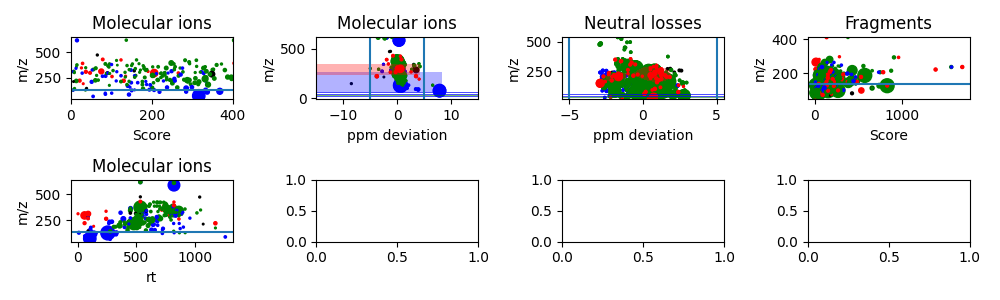

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=[10,3], layout="tight")

score = list(df["score"])
mz = list(df["mz"])
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = [str(list(df["approximation"])[i]) for i in range(len(df))]
score, mz, size_list, colorlist, subset_list, point_infos = get_cleaned_lists(score, mz, size_list, subset_list, point_infos)
ax[0,0].scatter(score, mz, size_list, colorlist)
ax[0,0].set_xlabel("Score")
ax[0,0].set_ylabel("m/z")
ax[0,0].set_xlim([0, 400])
ax[0,0].axhline(y=136)
ax[0,0].set_title("Molecular ions")

score = []
mz = []
subset_list = []
size_list = []
for i, row in df.iterrows():
    if row["mi_ppm_deviation"] == [None]:
        continue
    score.append(row["mi_ppm_deviation"])
    mz.append(row["mz"])
    subset_list.append(row["mi_subset"])
    size_list.append(row["intensity"])
score, mz, size_list, colorlist, subset_list, point_infos = get_cleaned_lists(score, mz, size_list, subset_list, point_infos)
ax[0,1].scatter(score, mz, size_list, colorlist)
create_shaded_areas(ax[0,1], score, mz, size_list, colorlist, subset_list, proportion=0.7) 
ax[0,1].set_xlabel("ppm deviation")
ax[0,1].set_ylabel("m/z")
ax[0,1].set_xlim([-15, 15])
ax[0,1].axhline(y=18, color="blue", linewidth=0.5)
ax[0,1].axhline(y=44, color="blue", linewidth=0.5)
ax[0,1].axhline(y=62, color="blue", linewidth=0.5)
ax[0,1].axhline(y=30, color="green", linewidth=0.4)
ax[0,1].axvline(x=5)
ax[0,1].axvline(x=-5)
ax[0,1].set_title("Molecular ions")

score = []
mz = []
subset_list = []
size_list = []
for i, row in df.iterrows():
    if row["nls_deviation"] == [None]:
        continue
    score.extend(row["nls_deviation"])
    mz.extend(row["nls_weight"])
    subset_list.extend([row["mi_subset"] for i in range(len(row["nls_deviation"]))])
    size_list.extend(row["frags_intensity"])
score, mz, size_list, colorlist, subset_list, point_infos = get_cleaned_lists(score, mz, size_list, subset_list, point_infos)
ax[0,2].scatter(score, mz, size_list, colorlist)
create_shaded_areas(ax[0,2], score, mz, size_list, colorlist, subset_list, proportion=0.7) 
ax[0,2].set_xlabel("ppm deviation")
ax[0,2].set_ylabel("m/z")
#ax[0,2].set_xlim([0, 30000])
ax[0,2].axhline(y=18, color="blue", linewidth=0.5)
ax[0,2].axhline(y=44, color="blue", linewidth=0.5)
ax[0,2].axhline(y=62, color="blue", linewidth=0.5)
ax[0,2].axhline(y=30, color="green", linewidth=0.4)
ax[0,2].axvline(x=5)
ax[0,2].axvline(x=-5)
ax[0,2].set_title("Neutral losses")


score = []
mz = []
subset_list = []
size_list = []
point_infos = []
for i, row in df.iterrows():
    score.extend(row["frags_score"])
    mz.extend(row["frags_weight"])
    subset_list.extend([row["mi_subset"] for i in range(len(row["nls_deviation"]))])
    size_list.extend(row["frags_intensity"])
    point_infos.extend([str(row["approximation"]) for i in range(len(row["nls_deviation"]))])
score, mz, size_list, colorlist, subset_list, point_info = get_cleaned_lists(score, mz, size_list, subset_list, point_infos)
ax[0,3].scatter(score, mz, size_list, colorlist)
ax[0,3].set_xlabel("Score")
ax[0,3].set_ylabel("m/z")
ax[0,3].set_ylim([45, max(mz)])
ax[0,3].axhline(y=136)
ax[0,3].set_title("Fragments")

rt = []
mz = []
subset_list = []
size_list = []
point_infos = []
for i, row in df.iterrows():
    rt.append(row["rt"])
    mz.append(row["mz"])
    subset_list.append(row["mi_subset"])
    size_list.append(row["intensity"])
    point_infos.append(str(row["approximation"]))
score, mz, size_list, colorlist, subset_list, point_info = get_cleaned_lists(rt, mz, size_list, subset_list, point_infos)
ax[1,0].scatter(rt, mz, size_list, colorlist)
ax[1,0].set_xlabel("rt")
ax[1,0].set_ylabel("m/z")
ax[1,0].set_ylim([45, max(mz)+20])
ax[1,0].axhline(y=136)
ax[1,0].set_title("Molecular ions")
print(df.shape)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(228, 30)


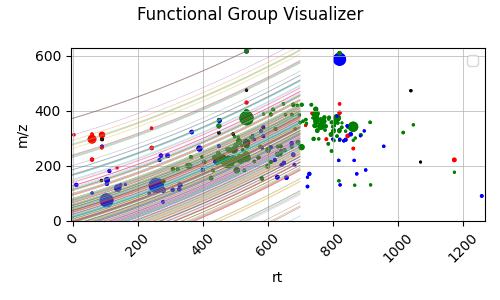

In [18]:
def plot_line(ax, slope, point_x, point_y):
    ranges = [-10, 700]
    # Define the coefficients a, b, and calculate c to ensure the curve passes through (x0, y0)
    a = 0.0002  # Coefficient for x^2
    b = 0.35  # Coefficient for x
    # Define the given point
    x0, y0 = point_x, point_y
    # Calculate c using the point (x0, y0)
    c = y0 - a * x0**2 - b * x0
    
    # Define the curve function
    def curve_function(x):
        return a * x**2 + b * x + c
    # Generate x values for plotting the curve
    x_values = np.linspace(ranges[0], ranges[1], 400)
    y_values = curve_function(x_values)
    # Plotting the curve
    plt.plot(x_values, y_values, linewidth=0.4, alpha=0.5)
    


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Functional Group Visualizer")

rt = []
mz = []
subset_list = []
size_list = []
point_infos = []
for i, row in df.iterrows():
    rt.append(row["rt"])
    mz.append(row["mz"])
    subset_list.append(row["mi_subset"])
    size_list.append(row["intensity"])
    point_infos.append(str(row["approximation"]) + "\n" + str(row["neutrallosses"]))
score, mz, size_list, colorlist, subset_list, point_info = get_cleaned_lists(rt, mz, size_list, subset_list, point_infos)
ax.scatter(rt, mz, size_list, colorlist)
insert_interactive_scatter(ax, rt, mz, point_info, colorlist, size_list)
ax.set_xlabel("rt")
ax.set_ylabel("m/z")
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which="both", linewidth=0.5)
for i in range(len(rt)):
    plot_line(ax, 0.39, rt[i], mz[i])
ax.legend()
ax.set_xlim([min(rt)-10, max(rt)+10])
ax.set_ylim([0, max(mz)+10])
print(df.shape)

C:\Users\nikarbac\AppData\Local\Temp\ipykernel_3448\3735844155.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20', num_colors)  # You can choose another colormap if you want
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


228
103
103
103
103
(228, 32)


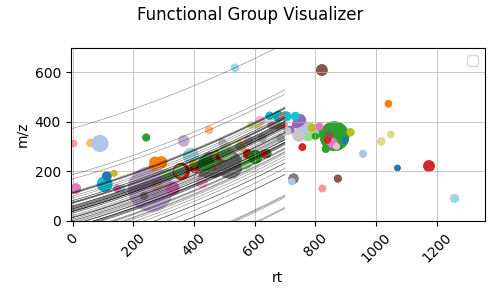

In [19]:
# CH2 subtraction
formulas = copy.deepcopy(list(df["approx_dict"]))
formulas_without_ch2 = []
for formula in formulas:
    curr_f = formula
    while True:
        if curr_f.get("H", 0) <=1 or curr_f.get("C", 0) <= 0:
            break
        curr_f["H"] = curr_f["H"] - 2
        curr_f["C"] = curr_f["C"] - 1
        if curr_f["H"] == 0:
            del curr_f["H"]
        if curr_f["C"] == 0:
            del curr_f["C"]
    formulas_without_ch2.append(curr_f)
for i in range(len(formulas_without_ch2)):
    formulas_without_ch2[i] = "".join([str(a) + str(n) for a, n in formulas_without_ch2[i].items()])
df["formulas_without_ch2"] = formulas_without_ch2


# Function to check cluster widths
def max_cluster_width(df, labels, group_col_name):
    clusters = [df[df['cluster'] == label][group_col_name] for label in np.unique(labels)]
    widths = [cluster.max() - cluster.min() for cluster in clusters]
    return max(widths)

# Initialize the number of clusters
num_bins = 2
max_width = 5

# Perform clustering and check cluster widths
while True:
    kmeans = KMeans(n_clusters=num_bins, random_state=0).fit(df[['rt']])
    df['cluster'] = kmeans.labels_
    if max_cluster_width(df, df['cluster'], "rt") <= max_width:
        break
    num_bins += 1

# Define a function to select the row to keep based on the conditions
def select_row(cluster_df):
    all_available_fragments = cluster_df["fragments"].to_list()
    all_available_fragments_strings = []
    for i in range(len(all_available_fragments)):
        all_available_fragments_strings.extend(all_available_fragments[i])
    all_available_fragments = list(set(all_available_fragments_strings))
    keep_rows = [cluster_df["mz"].idxmax()]
    
    return keep_rows
    
# Apply the function to each cluster
result_indices = df.groupby('cluster').apply(lambda cluster_df: select_row(cluster_df)).explode().astype(int).tolist()

# Select the rows with these indices
result_df = df.loc[result_indices].drop(columns='cluster')
result_df.sort_index(inplace=True)


print(len(df))
print(len(result_df))

#result_df = result_df[result_df["mi_subset"] == "CHON"]


def plot_line(ax, slope, point_x, point_y, linecolor="black"):
    ranges = [-10, 700]
    # Define the coefficients a, b, and calculate c to ensure the curve passes through (x0, y0)
    a = 0.0002  # Coefficient for x^2
    b = 0.35  # Coefficient for x
    # Define the given point
    x0, y0 = point_x, point_y
    # Calculate c using the point (x0, y0)
    c = y0 - a * x0**2 - b * x0
    
    # Define the curve function
    def curve_function(x):
        return a * x**2 + b * x + c
    # Generate x values for plotting the curve
    x_values = np.linspace(ranges[0], ranges[1], 400)
    y_values = curve_function(x_values)
    # Plotting the curve
    plt.plot(x_values, y_values, linewidth=0.4, alpha=0.5, color=linecolor)
    


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Functional Group Visualizer")

rt = []
mz = []
subset_list = []
size_list = []
point_infos = []
formulas_without_ch2 = []
for i, row in result_df.iterrows():
    rt.append(row["rt"])
    mz.append(row["mz"])
    subset_list.append(row["formulas_without_ch2"])
    size_list.append(row["intensity"])
    point_infos.append(str(row["approximation"]) + "\n" + str(row["neutrallosses"]) + "\n" + str(row["formulas_without_ch2"]))
    formulas_without_ch2.append(row["formulas_without_ch2"])
score, mz, size_list, colorlist, subset_list, point_info = get_cleaned_lists(rt, mz, size_list, subset_list, point_infos, defined_subset_colors=False)
for i in range(len(size_list)):
    size_list[i] = size_list[i] * 10
ax.scatter(rt, mz, size_list, colorlist)
insert_interactive_scatter(ax, rt, mz, point_info, colorlist, size_list)
ax.set_xlabel("rt")
ax.set_ylabel("m/z")
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which="both", linewidth=0.5)
print(len(formulas_without_ch2))
print(len(rt))
print(len(point_info))
for i in range(len(rt)):
    if not "Cl" in point_infos[i] and not "F" in point_infos[i] and "C" in point_infos[i] and "H" in point_infos[i] and "O" in point_infos[i] and "N" in point_infos[i] and not "S" in point_infos[i]:
        plot_line(ax, 0.39, rt[i], mz[i], linecolor="black")
ax.legend()
ax.set_xlim([min(rt)-10, max(rt)+100])
ax.set_ylim([0, max(mz)+80])
print(df.shape)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(220, 32)


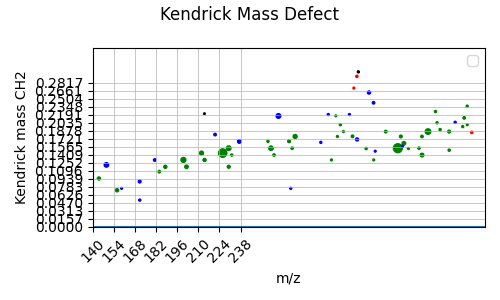

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Kendrick Mass Defect")


mz = list(result_df["mz"])
kendrick_mass = list(result_df["kendrick_mass_ch2"])
subset_list = list(result_df["mi_subset"])
size_list = list(result_df["intensity"])
point_infos = [str(list(result_df["approximation"])[i]) + "\n" + str(list(result_df["fragments"])[i]) + "\n" + str(list(result_df["neutrallosses"])[i]) + "\n" + str(list(result_df["rt"])[i]) for i in range(len(result_df))]
mz, kendrick_mass, size_list, colorlist, subset_list, point_info = get_cleaned_lists(mz, kendrick_mass, size_list, subset_list, point_infos)
insert_interactive_scatter(ax, mz, kendrick_mass, point_infos, colorlist, size_list)
ax.set_xlabel("m/z")
ax.set_ylabel("Kendrick mass CH2")
ax.set_xlim([150, 400])
ax.set_ylim([0, 0.35])
ax.axhline(y=0)
ax.set_yticks([(0.01565)*i for i in range(19)])
ax.set_xticks([(14)*i for i in range(10, 18, 1)])
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which="both", linewidth=0.5)
ax.legend()
print(df.shape)

In [21]:
df = df.drop(df[df.mi_ppm_deviation > 7].index)
df = df.drop(df[df.mi_ppm_deviation < -7].index)
print(df.shape)

(220, 32)


In [22]:
df.to_csv(filename.split(".")[0] + "_processed.txt", sep=",", decimal=".")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


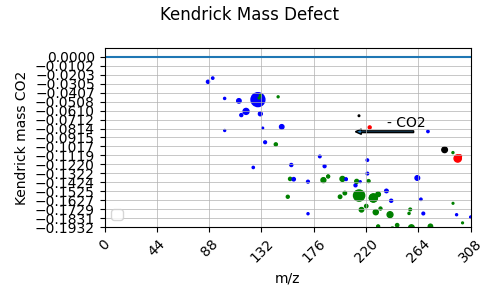

(220, 32)


In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Kendrick Mass Defect")

mz = list(df["mz"])
kendrick_mass = list(df["kendrick_mass_co2"])
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = [str(list(df["approximation"])[i]) + "\n" + str(list(df["fragments"])[i]) + "\n" + str(list(df["rt"])[i]) for i in range(len(df))]

mz, kendrick_mass, size_list, colorlist, subset_list, point_info_list = get_cleaned_lists(mz, kendrick_mass, size_list, subset_list, point_infos)
insert_interactive_scatter(ax, mz, kendrick_mass, point_infos, colorlist, size_list)
ax.set_xlabel("m/z")
ax.set_ylabel("Kendrick mass CO2")
ax.set_xlim([50, 250])
ax.set_ylim([-0.010, 0.01])
ax.axhline(y=0)
ax.set_yticks([(-0.01017)*i for i in range(20)])
ax.set_xticks([(44)*i for i in range(8)])
ax.tick_params(axis='x', rotation=45)
ax.grid(True, which="both", linewidth=0.5)
ax.arrow(260, -0.085, -44, 0, length_includes_head=False, width=0.002, head_length=5)
ax.text(270, -0.083, "- CO2", ha="right", va="bottom")
ax.legend()
plt.show()
print(df.shape)

C:\Users\nikarbac\AppData\Local\Temp\ipykernel_3448\2388769720.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(220, 32)


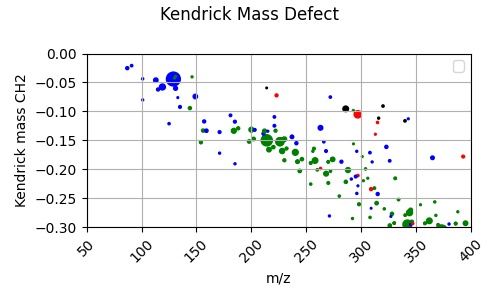

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Kendrick Mass Defect")


mz = list(df["mz"])
kendrick_mass = list(df["kendrick_mass_no3"])
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = [str(list(df["approximation"])[i]) + "\n" + str(list(df["fragments"])[i]) + "\n" + str(list(df["neutrallosses"])[i]) + "\n" + str(list(df["rt"])[i]) for i in range(len(df))]
mz, kendrick_mass, size_list, colorlist, subset_list, point_info = get_cleaned_lists(mz, kendrick_mass, size_list, subset_list, point_infos)
insert_interactive_scatter(ax, mz, kendrick_mass, point_infos, colorlist, size_list)
ax.set_xlabel("m/z")
ax.set_ylabel("Kendrick mass CH2")
ax.set_xlim([50, 400])
ax.set_ylim([-0.3, 0])
ax.grid()
ax.tick_params(axis='x', rotation=45)

ax.legend()
print(df.shape)

(220, 32)


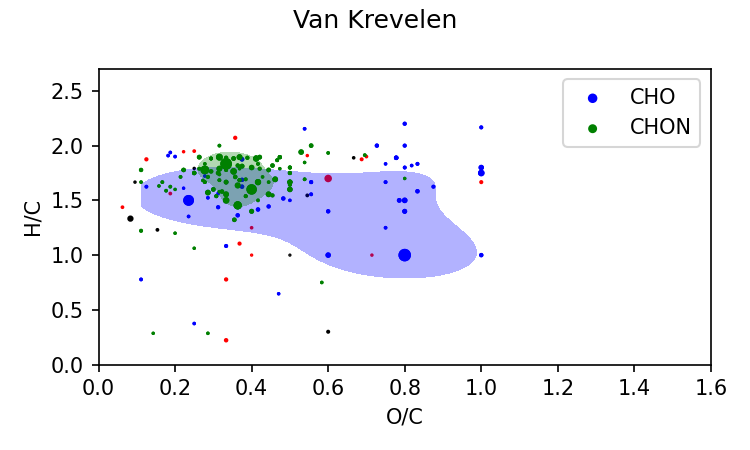

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight", dpi=150)
fig.suptitle("Van Krevelen")

hc_ratio = list(df["mi_hc_ratio"])
oc_ratio = list(df["mi_oc_ratio"])
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = []
for index, row in df.iterrows():
    point_infos.append(str(row["approximation"]) + "\n" + str(row["neutrallosses"]))
hc_ratio, oc_ratio, size_list, colorlist, subset_list, point_info = get_cleaned_lists(hc_ratio, oc_ratio, size_list, subset_list, point_infos)
size_list = [s/4 for s in size_list]
insert_interactive_scatter(ax, oc_ratio, hc_ratio, point_info, colorlist, size_list)
create_shaded_areas(ax, oc_ratio, hc_ratio, size_list, colorlist, subset_list, proportion=0.5, number_of_groups=2)
ax.set_xlabel("O/C")
ax.set_ylabel("H/C")
ax.set_xlim([0, 1.6])
ax.set_ylim([0, 2.7])
ax.legend()
print(df.shape)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'video_found': True, 'audio_found': False, 'metadata': {}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [1000, 1000], 'bitrate': None, 'fps': 50.0, 'codec_name': 'gif', 'profile': None}], 'input_number': 0}], 'duration': 21.6, 'bitrate': 19101, 'start': 0.0, 'default_video_input_number': 0, 'default_video_stream_number': 0, 'video_codec_name': 'gif', 'video_profile': None, 'video_size': [1000, 1000], 'video_bitrate': None, 'video_fps': 50.0, 'video_duration': 21.6, 'video_n_frames': 1080}
C:\Users\nikarbac\AppData\Local\Programs\Python\Python312\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe -i 3d_rotation.gif -loglevel error -f image2pipe -vf scale=1000:1000 -sws_flags bicubic -pix_fmt rgb24 -vcodec rawvideo -
MoviePy - Building video 3d_rotation.mp4.
MoviePy - Writing video 3d_rotation.mp4



MoviePy - Done !
MoviePy - video ready 3d_rotation.mp4
(220, 32)


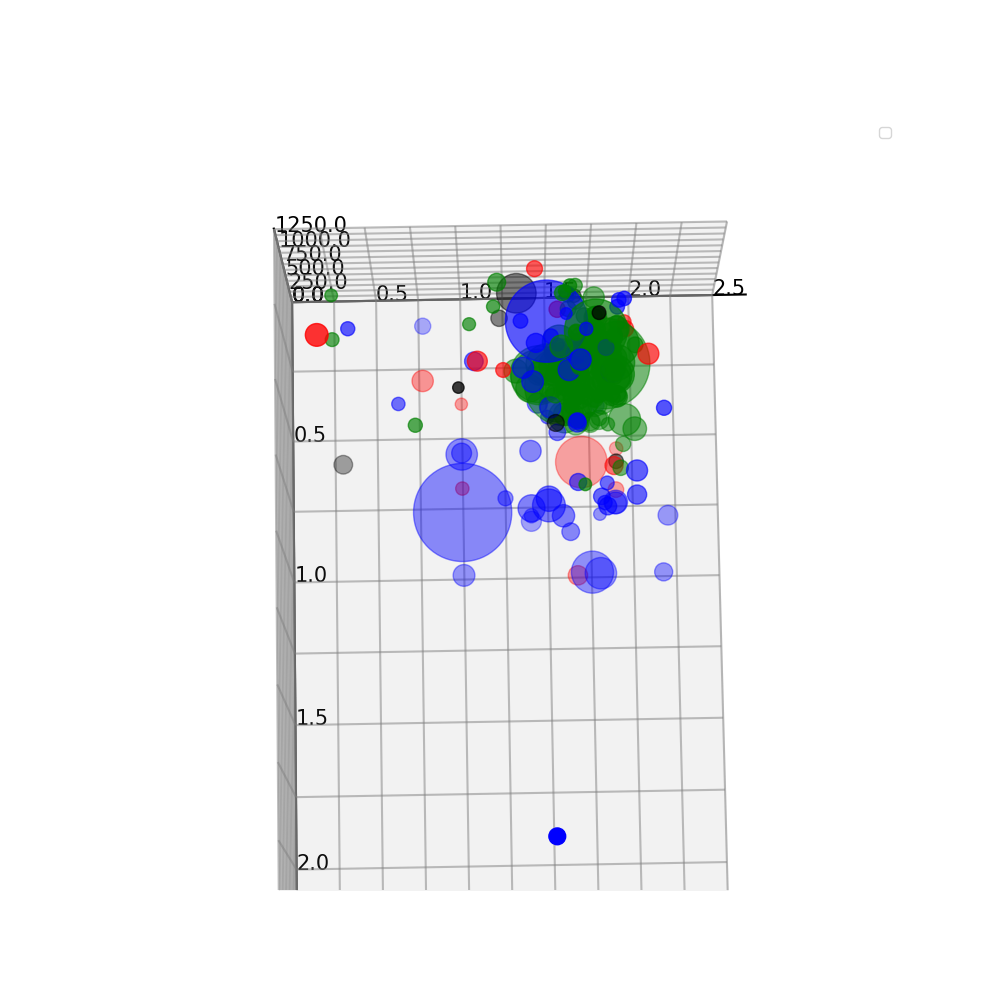

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Text3D
# Arrow3D utility to create 3D arrows
from mpl_toolkits.mplot3d.art3d import Line3D

def add_axis_arrow(ax, start, end, label, color='black', step=100, label_format="{:.1f}", fontsize=15):
    # Plot the arrow line
    ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], color=color)
    
    # Add an arrowhead
    ax.quiver(
        end[0], end[1], end[2],  # Arrowhead starting point
        (end[0] - start[0]) * 0.00001, 
        (end[1] - start[1]) * 0.00001, 
        (end[2] - start[2]) * 0.00001,
        color=color, arrow_length_ratio=0.3)

    # Determine the axis direction and generate ticks dynamically
    if end[0] != 0:  # X-axis
        ticks = np.arange(start[0], end[0] + step, step)
    elif end[1] != 0:  # Y-axis
        ticks = np.arange(start[1], end[1] + step, step)
    else:  # Z-axis
        ticks = np.arange(start[2], end[2] + step, step)
    
    # Add ticks and labels
    ticks = ticks[:-1]
    for tick in ticks:    
        tick_pos = [tick if end[i] else 0 for i in range(3)]
        ax.text(*tick_pos, label_format.format(tick), color=color, fontsize=fontsize)



fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

rt_list = list(df["rt"])
hc_ratio = list(df["mi_hc_ratio"])
oc_ratio = list(df["mi_oc_ratio"])
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = []
for index, row in df.iterrows():
    point_infos.append(str(row["approximation"]) + "\n" + str(row["neutrallosses"]))
hc_ratio, oc_ratio, rt_list, size_list, colorlist, subset_list, point_info = get_cleaned_lists_3d(hc_ratio, oc_ratio, rt_list, size_list, subset_list, point_infos)

size_list = [s*10 for s in size_list]

scatter = ax.scatter(oc_ratio, hc_ratio, rt_list, color=colorlist, s=size_list)

ax.set_xlabel("O/C")
ax.set_ylabel("H/C")
ax.set_zlabel("RT")
ax.set_xlim([0, 1.6])
ax.set_ylim([0, 2.7])
ax.legend()

# Static axes: Draw custom axes outside the 3D plot
def draw_static_axes():
    ax.set_axis_off()
    #ax.grid(False)
    
    x_upper_limit = max(oc_ratio)+0.5
    y_upper_limit = max(hc_ratio)+0.5
    z_upper_limit = max(rt_list)+50
    ## Define panes at the axes
    ## XY Plane (y=0)
    #xy_plane = [[0, 0, 0], [x_upper_limit, 0, 0], [x_upper_limit, 0, z_upper_limit], [0, 0, z_upper_limit]]
    ## YZ Plane (X=0)
    #yz_plane = [[0, 0, 0], [0, y_upper_limit, 0], [0, y_upper_limit, z_upper_limit], [0, 0, z_upper_limit]]
    ## XZ Plane (z=0)
    #xz_plane = [[0, 0, 0], [x_upper_limit, 0, 0], [x_upper_limit, y_upper_limit, 0], [0, y_upper_limit, 0]]
    ## Add the panes as translucent polygons
    #xz_pane = Poly3DCollection([xz_plane], alpha=0.2, color='gray')
    #ax.add_collection3d(xz_pane)
    #xy_pane = Poly3DCollection([xy_plane], alpha=0.2, color='gray')
    #ax.add_collection3d(xy_pane)
    #yz_pane = Poly3DCollection([yz_plane], alpha=0.2, color='gray')
    #ax.add_collection3d(yz_pane)

    #add arrows with ticks
    # Add arrows for X, Y, and Z axes
    add_axis_arrow(ax, np.array([0, 0, 0]), np.array([x_upper_limit, 0, 0]), label="X-axis", color='black', step=0.5)
    add_axis_arrow(ax, np.array([0, 0, 0]), np.array([0, y_upper_limit, 0]), label="Y-axis", color='black', step=0.5)
    add_axis_arrow(ax, np.array([0, 0, 0]), np.array([0, 0, z_upper_limit]), label="Z-axis", color='black', step=250)
    
    # Generate a wireframe overlay
    x = np.arange(0, x_upper_limit, 0.25)  # Adjust grid resolution
    y = np.arange(0, y_upper_limit, 0.25)
    z = np.arange(0, z_upper_limit, 100)
    # Create meshgrid for each axis-aligned plane
    # Create consistent meshgrids for each axis-aligned plane
    X_xy, Y_xy = np.meshgrid(x, y)  # XY plane
    X_xz, Z_xz = np.meshgrid(x, z)  # XZ plane
    Y_yz, Z_yz = np.meshgrid(y, z)  # YZ plane
    
    # Plot the wireframe grids
    ax.plot_wireframe(X_xy, Y_xy, np.zeros_like(X_xy), color='gray', alpha=0.5)  # Z=0 (XY plane)
    ax.plot_wireframe(X_xz, np.zeros_like(X_xz), Z_xz, color='gray', alpha=0.5)  # Y=0 (XZ plane)
    ax.plot_wireframe(np.zeros_like(Y_yz), Y_yz, Z_yz, color='gray', alpha=0.5)  # X=0 (YZ plane)

    # XY Plane (y=0)
    xy_plane = [[0, 0, 0], [(X_xy[-1][-1]), 0, 0], [(X_xy[-1][-1]), 0, (Z_yz[-1][-1])], [0, 0, (Z_yz[-1][-1])]]
    # YZ Plane (X=0)
    yz_plane = [[0, 0, 0], [0, (Y_xy[-1][-1]), 0], [0, (Y_xy[-1][-1]), (Z_yz[-1][-1])], [0, 0, (Z_yz[-1][-1])]]
    # XZ Plane (z=0)
    xz_plane = [[0, 0, 0], [(X_xy[-1][-1]), 0, 0], [(X_xy[-1][-1]), (Y_xy[-1][-1]), 0], [0, (Y_xy[-1][-1]), 0]]
    # Add the panes as translucent polygons
    xz_pane = Poly3DCollection([xz_plane], alpha=0.1, color='gray')
    ax.add_collection3d(xz_pane)
    xy_pane = Poly3DCollection([xy_plane], alpha=0.1, color='gray')
    ax.add_collection3d(xy_pane)
    yz_pane = Poly3DCollection([yz_plane], alpha=0.1, color='gray')
    ax.add_collection3d(yz_pane)
    
    return ax

static_axes = draw_static_axes()

# Function to update the view angle
def update(frame):
    ax.view_init(elev=-10+(90*(frame/1080)), azim=frame)  # Rotate azimuth
    return ax,

# Create the animation
frames = 1080# Number of frames for a full rotation
ani = FuncAnimation(fig, update, frames=frames, interval=30, blit=False)

# Save the animation as a video file (requires ffmpeg or pillow)
save_as_gif = True  # Set to False if you want an MP4

ani.save('3d_rotation.gif', writer=PillowWriter(fps=40))

import moviepy as mp
clip = mp.VideoFileClip("3d_rotation.gif")
clip.write_videofile("3d_rotation.mp4")
import os
os.remove("3d_rotation.gif")

print(df.shape)

(220, 32)


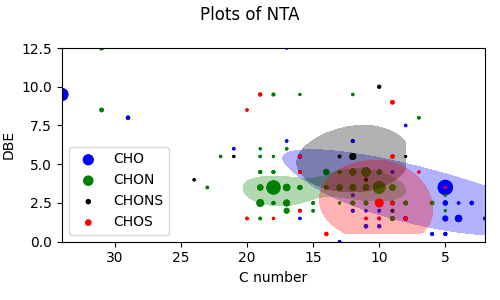

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Plots of NTA")

dbe = list(df["mi_dbe"])
c_number_list = []
for index, row in df.iterrows():
    c_number_list.append(row["approx_dict"].get("C", 0))
#print(list(df["approx_dict"]))
#print(list(df["approximation"]))
#print(len(c_number_list))
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = list(df["approximation"])
c_number_list, dbe, size_list, colorlist, subset_list, point_info = get_cleaned_lists(c_number_list, dbe, size_list, subset_list, point_infos)
insert_interactive_scatter(ax, c_number_list, dbe, point_info, colorlist, size_list)
create_shaded_areas(ax, c_number_list, dbe, size_list, colorlist, subset_list, proportion=0.5, number_of_groups=4)
ax.xaxis.set_inverted(True)
ax.set_xlabel("C number")
ax.set_ylabel("DBE")
ax.legend()
#ax.set_xlim([0, 4])
#ax.set_ylim([0, 4])
print(df.shape)

(220, 32)


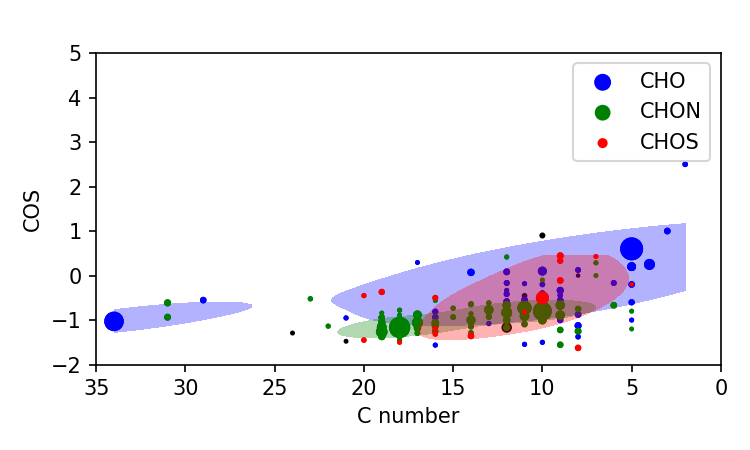

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight", dpi=150)
fig.suptitle("")

mi_cos = list(df["mi_cos"])
c_number_list = []
for index, row in df.iterrows():
    c_number_list.append(row["approx_dict"].get("C", 0))
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = [str(row["approximation"]) + "\n" + str(row["neutrallosses"]) for index, row in df.iterrows()]
#point_infos = list(df["approximation"])
c_number_list, mi_cos, size_list, colorlist, subset_list, point_info = get_cleaned_lists(c_number_list, mi_cos, size_list, subset_list, point_infos)
insert_interactive_scatter(ax, c_number_list, mi_cos, point_info, colorlist, size_list)
create_shaded_areas(ax, c_number_list, mi_cos, size_list, colorlist, subset_list, proportion=0.3, number_of_groups=3)        
ax.set_xlabel("C number")
ax.set_ylabel("COS")
ax.set_xlim([max(c_number_list)+1, 0])
ax.legend()
ax.set_ylim([-2, 5])
print(df.shape)

(220, 32)


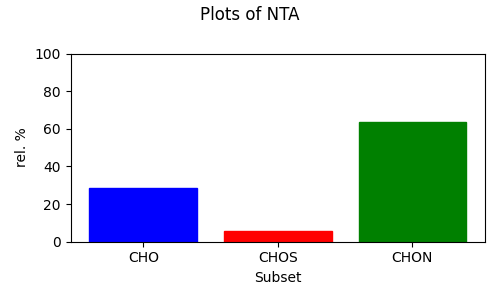

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Plots of NTA")

c_number_list = []
for index, row in df.iterrows():
    c_number_list.append(row["approx_dict"].get("C", 0))
subset_list = list(df["mi_subset"])
size_list = list(df["intensity"])
point_infos = list(df["approximation"])
_, _, size_list, colorlist, subset_list, point_info = get_cleaned_lists(c_number_list, c_number_list, size_list, subset_list, point_infos)
sizes_for_subsets = {}
for i in range(len(size_list)):
    if subset_list[i] in sizes_for_subsets:
        sizes_for_subsets[subset_list[i]] += size_list[i]
    else:
        sizes_for_subsets[subset_list[i]] = size_list[i]
sizes_list = (list(sizes_for_subsets.values()))
subsets_list = list(sizes_for_subsets.keys())
colors_list = []
for entry in subsets_list:
    for i in range(len(subset_list)):
        if subset_list[i] == entry:
            colors_list.append(colorlist[i])
            break
high_subsets_list = []
high_sizes_list = []
high_colors_list = []
for i in range(len(sizes_list)):
    if (sizes_list[i]/max(sizes_list)) >= 0.05:
        high_subsets_list.append(subsets_list[i])
        high_sizes_list.append(sizes_list[i])
        high_colors_list.append(colors_list[i])
barlist = ax.bar(high_subsets_list, [100*i/sum(sizes_list) for i in high_sizes_list])
ax.set_ylim([0, 100])
for i in range(len(barlist)):
    barlist[i].set_color(high_colors_list[i])
ax.set_ylabel("rel. %")
ax.set_xlabel("Subset")
print(df.shape)

max() iterable argument is empty
asd
max() iterable argument is empty
[]

asd
max() iterable argument is empty
[]

Traceback (most recent call last):
  File "C:\Users\nikarbac\AppData\Local\Temp\ipykernel_6396\935766778.py", line 17, in create_shaded_areas
    plot_kde_subset(ax, x_subset, y_subset, sizes_subset, color=color, label=label, proportion=proportion)
  File "C:\Users\nikarbac\AppData\Local\Temp\ipykernel_6396\1342102222.py", line 4, in plot_kde_subset
    kde = gaussian_kde(data_subset, weights=weights)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nikarbac\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_kde.py", line 223, in __init__
    raise ValueError(msg)
ValueError: Number of dimensions is greater than number of samples. This results in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Note that `gaussian_kde` interprets each *column* of `dataset` to be a point; 

ValueError: 'c' argument has 10 elements, which is inconsistent with 'x' and 'y' with size 9.

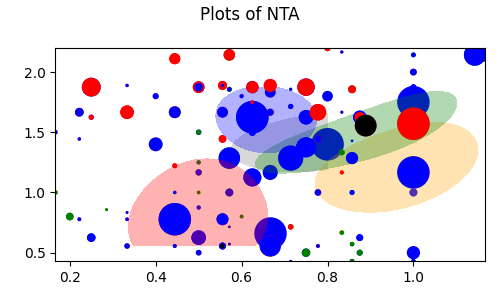

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5,3], layout="tight")
fig.suptitle("Plots of NTA")

hc_list = []
avg_hc_list = []
avg_oc_list = []
avg_color_list = []
oc_list = []
sizes_list = []
subsets_list = []
point_infos = []
c_number_list = []
for index, row in df.iterrows():
    c_number_list.append(row["approx_dict"].get("C", 0))

for i in range(2, 11, 1):
    keep_c_number = i
    try:
        df["c_number"] = c_number_list
        hc_ratio = list(df[df["c_number"] == keep_c_number]["mi_hc_ratio"])
        hc_list.append(hc_ratio)
        oc_ratio = list(df[df["c_number"] == keep_c_number]["mi_oc_ratio"])
        oc_list.append(oc_ratio)
        size_list = list(df[df["c_number"] == keep_c_number]["intensity"])
        sizes_list.append(size_list)
        subset_list = list(df[df["c_number"] == keep_c_number]["mi_subset"])
        subsets_list.append(subset_list)
        point_info = list(df[df["c_number"] == keep_c_number]["approximation"])
        point_infos.append(point_info)
        mi_formulas = list(df[df["c_number"] == keep_c_number]["approx_dict"])
        mi_formulas = ["".join([str(a) + str(n) for a, n in formula_dict.items()]) for formula_dict in mi_formulas]
        mi_formulas = list(zip(mi_formulas, size_list))
        mi_formulas = sorted(mi_formulas, key=lambda x: x[1], reverse=True)
        max_size_intensity = max(size_list)
        mi_formulas = [(f, s*100/max_size_intensity) for f, s in mi_formulas]
        print_mi_formulas = [(f, s) for f, s in mi_formulas if "H" in f and "O" in f and "C" in f and not "Cl" in f and not "F" in f and "S" in f and not "N" in f]
        print(print_mi_formulas)
        print()
        avg_hc_list.append(sum([hc_ratio[k]*size_list[k] for k in range(len(hc_ratio))])  /  (sum(size_list)))
        avg_oc_list.append(sum([oc_ratio[k]*size_list[k] for k in range(len(oc_ratio))])  /  (sum(size_list)))
        
    except Exception as e:
        print(e)
        hc_list.append([])
        oc_list.append([])
        sizes_list.append([])
        subsets_list.append([])
        point_infos.append([])
        avg_hc_list.append(0)
        avg_oc_list.append(0)
        avg_color_list.append("black")
        
    n = i-2
    if i == 10:
        color = "red"
    if i == 9:
        color = "blue"
    if i == 8:
        color = "green"
    if i == 7:
        color = "orange"
    if i == 6:
        color="gray"
    if i == 5:
        color = "magenta"
    if i == 4:
        color="cyan"
    if i == 3:
        color="lime"
    if i == 2:
        color="pink"
    avg_color_list.append(color)
    try:
        hc_ratio, oc_ratio, size_list, colorlist, subset_list, point_info = get_cleaned_lists(hc_list[n], oc_list[n], sizes_list[n], subsets_list[n], point_infos[n])
        #insert_interactive_scatter(ax, oc_ratio, [i for y in range(len(oc_ratio))], point_info, colorlist, size_list)
        create_shaded_areas(ax, oc_ratio, hc_ratio, size_list, [color for k in range(len(oc_ratio))], [i for k in range(len(oc_ratio))], proportion=0.7)
        #create_shaded_areas(ax, oc_ratio, [i for y in range(len(oc_ratio))], size_list, [color for k in range(len(oc_ratio))], [i for k in range(len(oc_ratio))], proportion=0.3) 
        insert_interactive_scatter(ax, oc_ratio, hc_ratio, point_info, colorlist, size_list)
    except Exception as e:
        print("asd")
        print(e)

ax.scatter(avg_oc_list, avg_hc_list, color=avg_color_list, marker="x", s=100, linewidth=5)
#hc_ratio, oc_ratio, size_list, colorlist, subset_list, point_info = get_cleaned_lists([hc_list[n][i] for n in range(len(hc_list)) for i in range(len(hc_list[n]))],
#                                                                                      [oc_list[n][i] for n in range(len(oc_list)) for i in range(len(oc_list[n]))],
#                                                                                      [round(sizes_list[n][i], 1) for n in range(len(sizes_list)) for i in range(len(sizes_list[n]))],
#                                                                                      [subsets_list[n][i] for n in range(len(subsets_list)) for i in range(len(subsets_list[n]))],
#                                                                                      [point_infos[n][i] for n in range(len(point_infos)) for i in range(len(point_infos[n]))])
#insert_interactive_scatter(ax, oc_ratio, hc_ratio, point_info, colorlist, size_list)
ax.set_xlabel("O/C")
ax.set_ylabel("H/C")
ax.set_xlim([0, 1.5])
ax.set_ylim([0, 2])
ax.legend()
#ax.axvline(x=1.6)